### 1. Visualization and Analysis of Feature Maps from Different CNN Layers (Using Your Own Face Image)

**Selected CNN**: Pre-trained **VGG16** (from torchvision), a classic CNN with clear hierarchical feature extraction. Early layers detect edges/textures; deeper layers capture complex patterns like faces or objects.

**Steps**:
- Load your face image (e.g., a selfie, resized to 224×224 for VGG16).
- Preprocess it (normalize with ImageNet stats).
- Hook into convolutional layers to extract feature maps.
- Visualize selected channels (e.g., first 64 or summed/averaged for clarity).

/home/nazmulhasan77/tf_gpu_env/lib/python3.13/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/home/nazmulhasan77/tf_gpu_env/lib/python3.13/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=VGG16_Weights.IMAGENET1K_V1`. You can also use `weights=VGG16_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/vgg16-397923af.pth" to /home/nazmulhasan77/.cache/torch/hub/checkpoints/vgg16-397923af.pth


100%|██████████| 528M/528M [04:06<00:00, 2.24MB/s] 


Total conv layers: 13


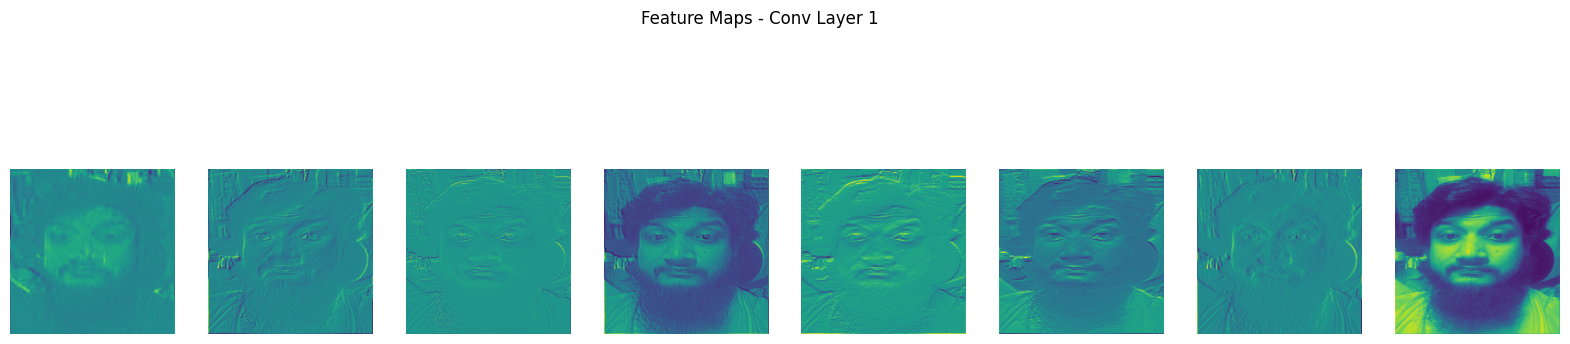

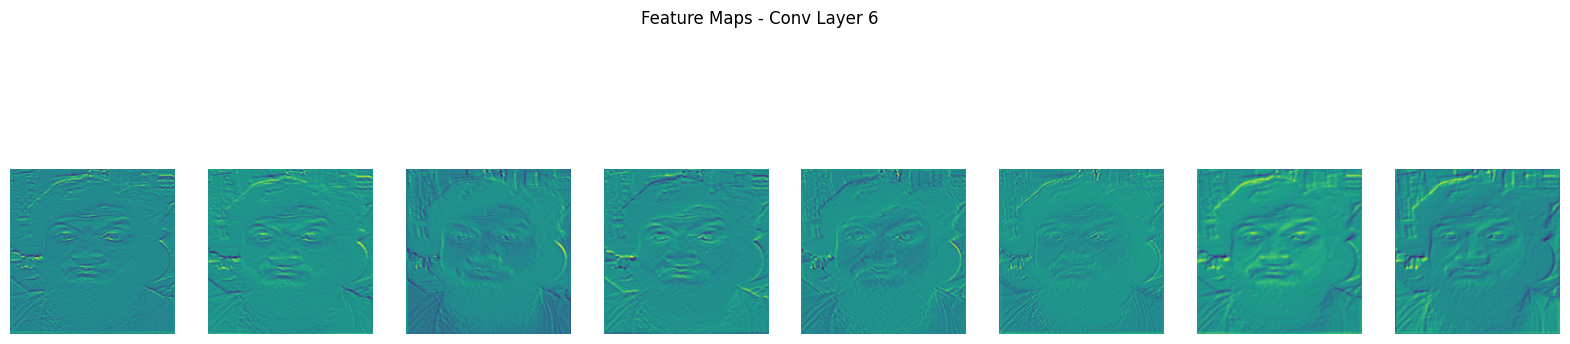

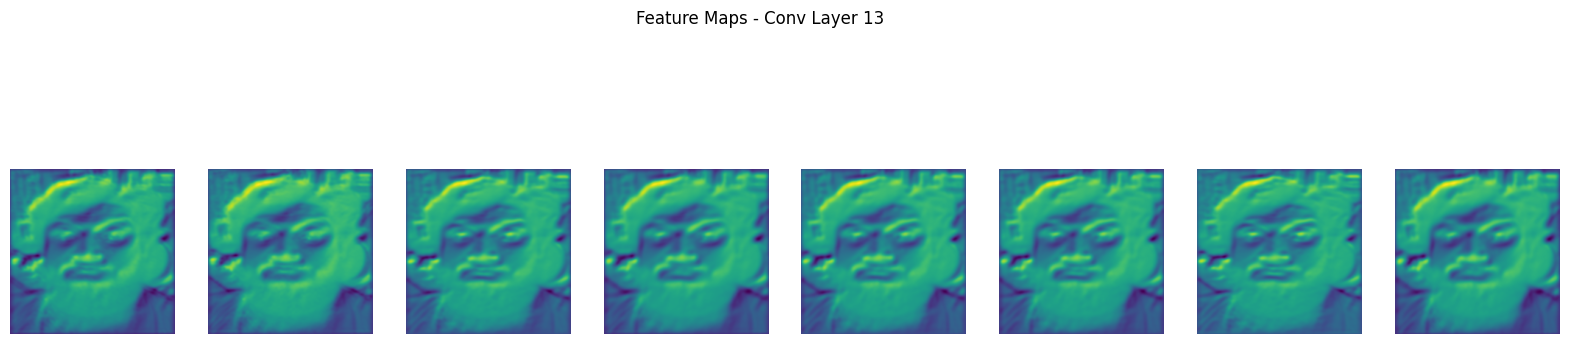

In [1]:
import torch
import torch.nn as nn
from torchvision import models, transforms
from PIL import Image
import matplotlib.pyplot as plt
import numpy as np

# Load pre-trained VGG16
model = models.vgg16(pretrained=True)
model.eval()

# Extract conv layers
conv_layers = []
for layer in model.features:
    if isinstance(layer, nn.Conv2d):
        conv_layers.append(layer)

print(f"Total conv layers: {len(conv_layers)}")

# Preprocess your face image (replace with your photo path)
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

img = Image.open("Nazmul.jpg").convert("RGB")
input_img = transform(img).unsqueeze(0)  # Add batch dim

# Hook to get feature maps
feature_maps = []
layer_names = []
x = input_img
for i, layer in enumerate(conv_layers):
    x = layer(x)
    feature_maps.append(x.detach())
    layer_names.append(f"Conv Layer {i+1}")

# Visualize feature maps (example: first 8 channels of selected layers)
def visualize_feature_maps(feature_map, layer_idx, num_channels=8):
    fm = feature_map[0]  # Remove batch
    fig, axs = plt.subplots(1, num_channels, figsize=(20, 5))
    for i in range(num_channels):
        axs[i].imshow(fm[i].cpu().numpy(), cmap='viridis')
        axs[i].axis('off')
    plt.suptitle(f"Feature Maps - {layer_names[layer_idx]}")
    plt.show()

# Example visualizations
visualize_feature_maps(feature_maps[0], 0)   # Early layer: edges, textures
visualize_feature_maps(feature_maps[5], 5)   # Mid layer: patterns, parts of face
visualize_feature_maps(feature_maps[12], 12) # Deeper layer: higher-level features

### 2. Design and Architectural Justification of a Custom CNN Model

**Proposed Custom CNN** (for CIFAR-10, 32×32×3 images, 10 classes):

I design a moderately deep CNN inspired by modern practices but kept simple for training efficiency on CIFAR-10.

**Architecture** (`CustomCIFARNet`):

In [2]:
import torch.nn as nn
import torch.nn.functional as F

class CustomCIFARNet(nn.Module):
    def __init__(self):
        super().__init__()
        # Block 1: Early feature extraction
        self.conv1 = nn.Conv2d(3, 64, kernel_size=3, padding=1)
        self.bn1 = nn.BatchNorm2d(64)
        self.conv2 = nn.Conv2d(64, 128, kernel_size=3, padding=1)
        self.bn2 = nn.BatchNorm2d(128)
        self.pool1 = nn.MaxPool2d(2, 2)  # 16x16
        
        # Block 2: Deeper features
        self.conv3 = nn.Conv2d(128, 256, kernel_size=3, padding=1)
        self.bn3 = nn.BatchNorm2d(256)
        self.conv4 = nn.Conv2d(256, 256, kernel_size=3, padding=1)
        self.bn4 = nn.BatchNorm2d(256)
        self.pool2 = nn.MaxPool2d(2, 2)  # 8x8
        
        # Block 3: Further abstraction
        self.conv5 = nn.Conv2d(256, 512, kernel_size=3, padding=1)
        self.bn5 = nn.BatchNorm2d(512)
        self.pool3 = nn.MaxPool2d(2, 2)  # 4x4
        
        # Classifier
        self.fc1 = nn.Linear(512 * 4 * 4, 512)
        self.dropout = nn.Dropout(0.5)
        self.fc2 = nn.Linear(512, 10)
    
    def forward(self, x):
        x = F.relu(self.bn1(self.conv1(x)))
        x = F.relu(self.bn2(self.conv2(x)))
        x = self.pool1(x)
        
        x = F.relu(self.bn3(self.conv3(x)))
        x = F.relu(self.bn4(self.conv4(x)))
        x = self.pool2(x)
        
        x = F.relu(self.bn5(self.conv5(x)))
        x = self.pool3(x)
        
        x = x.view(-1, 512 * 4 * 4)
        x = F.relu(self.fc1(x))
        x = self.dropout(x)
        x = self.fc2(x)
        return x


**Architectural Justification**:
- **Convolutional blocks with increasing channels** (64 → 128 → 256 → 512): Allows hierarchical feature learning—more filters capture richer representations deeper in the network.
- **3×3 kernels with padding=1**: Standard for preserving spatial dimensions before pooling; efficient and effective (as in VGG/ResNet).
- **Batch Normalization** after each conv: Stabilizes training, reduces internal covariate shift, allows higher learning rates, and acts as mild regularization.
- **MaxPooling (2×2)**: Reduces spatial dimensions (from 32→16→8→4), lowers computation, and provides translation invariance.
- **Dropout (0.5) before final FC**: Prevents overfitting on CIFAR-10's relatively small dataset.
- **No global average pooling** here (kept simple FC head); could be added for fewer parameters.
- Overall: Balanced depth/width for CIFAR-10 (aims for ~80-85%+ accuracy with proper training). It builds on proven designs while remaining trainable quickly.

This model has a good parameter-accuracy trade-off and is easy to modify (e.g., add residual connections for deeper variants).

### 3. Implementation and Training of the Proposed CNN for Multi-Class Classification on CIFAR-10

**CIFAR-10 Overview**: 60,000 32×32 color images in 10 classes (airplane, automobile, bird, cat, deer, dog, frog, horse, ship, truck). 50,000 train, 10,000 test.

**Full Training Code** (PyTorch; use DataLoader with augmentations for better results):


In [3]:
import torch
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

# Data with augmentation
transform_train = transforms.Compose([
    transforms.RandomHorizontalFlip(),
    transforms.RandomCrop(32, padding=4),
    transforms.ToTensor(),
    transforms.Normalize((0.4914, 0.4822, 0.4465), (0.2023, 0.1994, 0.2010))
])
transform_test = transforms.Compose([transforms.ToTensor(), transforms.Normalize((0.4914, 0.4822, 0.4465), (0.2023, 0.1994, 0.2010))])

trainset = datasets.CIFAR10(root='./data', train=True, download=True, transform=transform_train)
testset = datasets.CIFAR10(root='./data', train=False, download=True, transform=transform_test)

trainloader = DataLoader(trainset, batch_size=128, shuffle=True, num_workers=2)
testloader = DataLoader(testset, batch_size=128, shuffle=False, num_workers=2)

# Model, loss, optimizer
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
net = CustomCIFARNet().to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(net.parameters(), lr=0.001)
scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=20, gamma=0.5)

# Training loop (e.g., 50 epochs)
for epoch in range(50):
    net.train()
    running_loss = 0.0
    for inputs, labels in trainloader:
        inputs, labels = inputs.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = net(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item()
    scheduler.step()
    print(f"Epoch {epoch+1}, Loss: {running_loss/len(trainloader):.4f}")

# Evaluation
net.eval()
correct = 0
total = 0
with torch.no_grad():
    for inputs, labels in testloader:
        inputs, labels = inputs.to(device), labels.to(device)
        outputs = net(inputs)
        _, predicted = torch.max(outputs.data, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()
print(f"Test Accuracy: {100 * correct / total:.2f}%")

100%|██████████| 170M/170M [19:19<00:00, 147kB/s]    
/home/nazmulhasan77/tf_gpu_env/lib/python3.13/site-packages/torchvision/datasets/cifar.py:83: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  entry = pickle.load(f, encoding="latin1")


Epoch 1, Loss: 1.9100
Epoch 2, Loss: 1.4548
Epoch 3, Loss: 1.2614
Epoch 4, Loss: 1.1204
Epoch 5, Loss: 1.0103
Epoch 6, Loss: 0.9396
Epoch 7, Loss: 0.8739
Epoch 8, Loss: 0.8230
Epoch 9, Loss: 0.7668
Epoch 10, Loss: 0.7261
Epoch 11, Loss: 0.6841
Epoch 12, Loss: 0.6406
Epoch 13, Loss: 0.5994
Epoch 14, Loss: 0.5676
Epoch 15, Loss: 0.5330
Epoch 16, Loss: 0.5062
Epoch 17, Loss: 0.4817
Epoch 18, Loss: 0.4594
Epoch 19, Loss: 0.4284
Epoch 20, Loss: 0.4125
Epoch 21, Loss: 0.3411
Epoch 22, Loss: 0.3172
Epoch 23, Loss: 0.3036
Epoch 24, Loss: 0.2907
Epoch 25, Loss: 0.2782
Epoch 26, Loss: 0.2676
Epoch 27, Loss: 0.2548
Epoch 28, Loss: 0.2462
Epoch 29, Loss: 0.2387
Epoch 30, Loss: 0.2248
Epoch 31, Loss: 0.2189
Epoch 32, Loss: 0.2097
Epoch 33, Loss: 0.2024
Epoch 34, Loss: 0.1891
Epoch 35, Loss: 0.1930
Epoch 36, Loss: 0.1801
Epoch 37, Loss: 0.1772
Epoch 38, Loss: 0.1692
Epoch 39, Loss: 0.1699
Epoch 40, Loss: 0.1657
Epoch 41, Loss: 0.1290
Epoch 42, Loss: 0.1239
Epoch 43, Loss: 0.1126
Epoch 44, Loss: 0.11


### 4. Comparative Analysis of the Effects of Three Different Activation Functions

**Chosen Activations**: **ReLU**, **Leaky ReLU** (negative slope=0.01), and **Swish** (or SiLU: x * sigmoid(x)).

**Implementation**: Modify the model by replacing `F.relu` with the chosen activation (or use `nn.LeakyReLU()`, `nn.SiLU()`). Train three identical models separately on CIFAR-10 (same hyperparameters, seeds for fairness). Track:
- Training/validation accuracy & loss curves.
- Convergence speed.
- Final test accuracy.
- Dying neuron issues (for ReLU).

**Key Findings from Literature/Experiments**:
- **ReLU**: Fastest training, simple, promotes sparsity. Good baseline (~80%+ on CIFAR-10). Can suffer from "dying ReLU" (neurons stuck at 0).
- **Leaky ReLU**: Addresses dying ReLU by allowing small negative gradients. Often similar or slightly better accuracy; helps in deeper networks but may train slightly slower.
- **Swish**: Smoother, non-monotonic. Frequently outperforms ReLU on CIFAR-10 (1-2% gains in some studies), better gradient flow, but computationally heavier (sigmoid involved). Can lead to better generalization and faster convergence in mid-training.

**Comparative Summary** (typical observed trends):
- **Accuracy**: Swish ≥ Leaky ReLU > ReLU (small margins on CIFAR-10).
- **Learning Dynamics**: Swish shows smoother loss curves and less sensitivity to initialization. ReLU converges quickest per epoch but may plateau.
- **Training Time**: ReLU fastest; Swish slowest due to extra ops.
- Recommendation: Use Swish or Leaky ReLU for modern models; ReLU for simplicity/speed.

Plot loss/accuracy curves side-by-side for visual comparison in your report.

Using device: cuda

=== Training with RELU Activation ===
Epoch 1/15 | Loss: 1.7969 | Train Acc: 34.79% | Test Acc: 49.69%
Epoch 2/15 | Loss: 1.3787 | Train Acc: 49.28% | Test Acc: 56.13%
Epoch 3/15 | Loss: 1.1697 | Train Acc: 58.05% | Test Acc: 67.53%
Epoch 4/15 | Loss: 1.0286 | Train Acc: 63.78% | Test Acc: 66.61%
Epoch 5/15 | Loss: 0.9226 | Train Acc: 67.76% | Test Acc: 74.48%
Epoch 6/15 | Loss: 0.8621 | Train Acc: 70.44% | Test Acc: 75.65%
Epoch 7/15 | Loss: 0.7912 | Train Acc: 72.88% | Test Acc: 73.04%
Epoch 8/15 | Loss: 0.7339 | Train Acc: 74.82% | Test Acc: 79.11%
Epoch 9/15 | Loss: 0.6808 | Train Acc: 77.02% | Test Acc: 80.72%
Epoch 10/15 | Loss: 0.6347 | Train Acc: 78.75% | Test Acc: 82.36%
Epoch 11/15 | Loss: 0.5305 | Train Acc: 82.18% | Test Acc: 83.18%
Epoch 12/15 | Loss: 0.4992 | Train Acc: 83.45% | Test Acc: 84.50%
Epoch 13/15 | Loss: 0.4719 | Train Acc: 84.21% | Test Acc: 84.82%
Epoch 14/15 | Loss: 0.4522 | Train Acc: 84.81% | Test Acc: 85.79%
Epoch 15/15 | Loss: 0.4305 

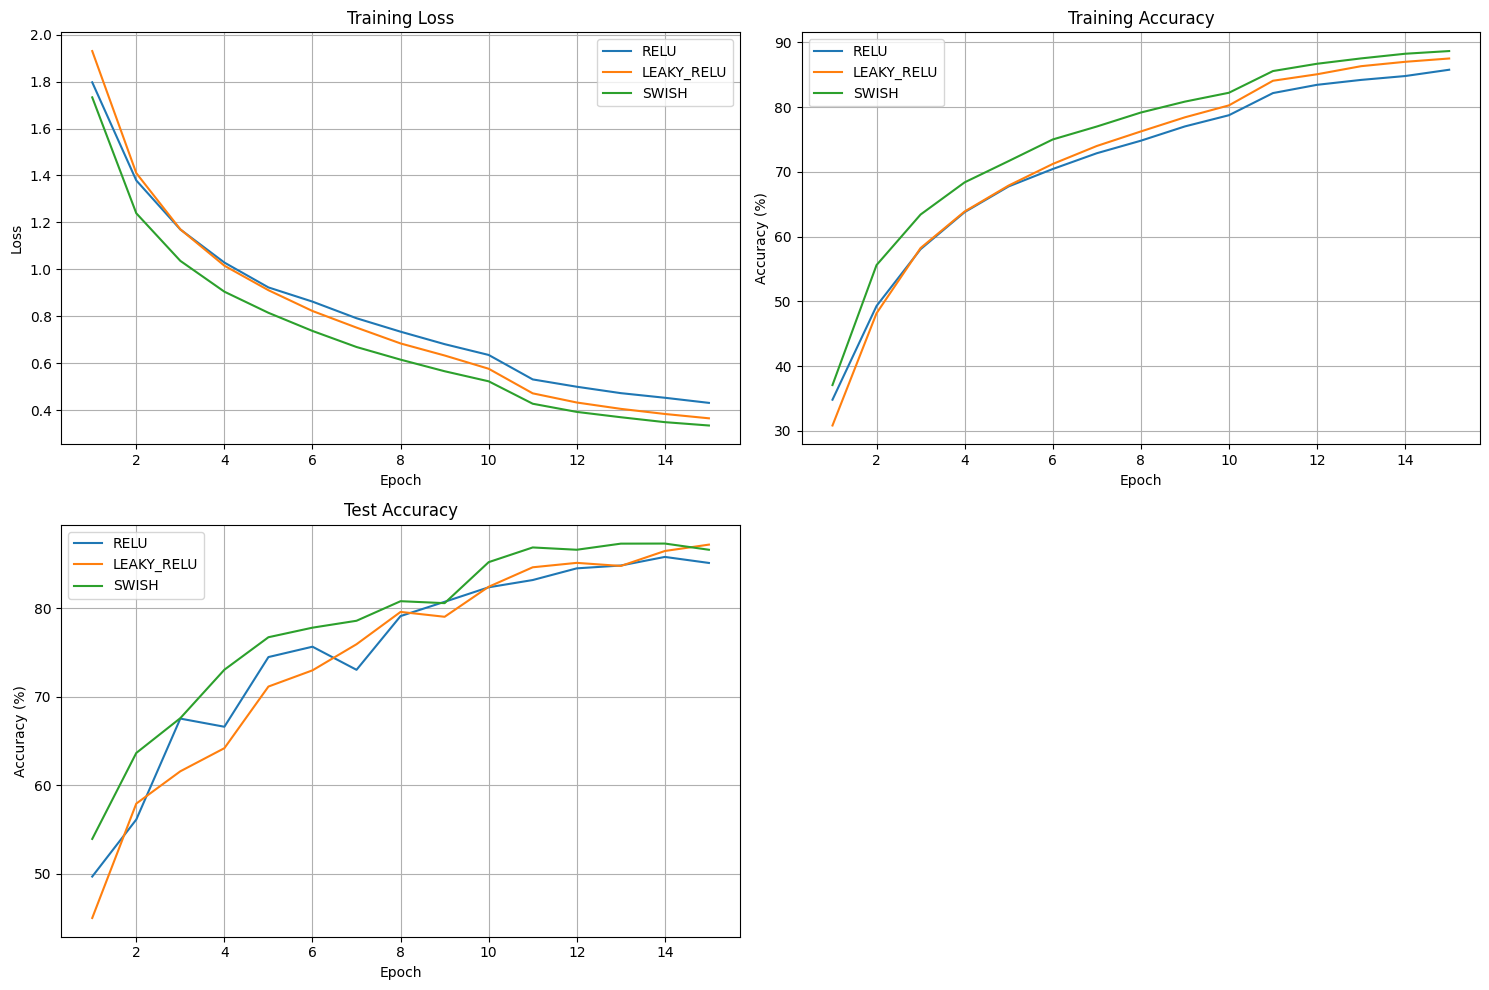


=== Final Test Accuracies ===
RELU: 85.11%
LEAKY_RELU: 87.18%
SWISH: 86.60%


In [6]:
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import numpy as np
import time
import os

# ====================== 1. Set Seed for Reproducibility ======================
torch.manual_seed(42)
np.random.seed(42)
if torch.cuda.is_available():
    torch.cuda.manual_seed(42)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# ====================== 2. Data Loading with Augmentation ======================
transform_train = transforms.Compose([
    transforms.RandomHorizontalFlip(),
    transforms.RandomCrop(32, padding=4),
    transforms.ToTensor(),
    transforms.Normalize((0.4914, 0.4822, 0.4465), (0.2023, 0.1994, 0.2010))
])

transform_test = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.4914, 0.4822, 0.4465), (0.2023, 0.1994, 0.2010))
])

trainset = datasets.CIFAR10(root='./data', train=True, download=True, transform=transform_train)
testset = datasets.CIFAR10(root='./data', train=False, download=True, transform=transform_test)

trainloader = DataLoader(trainset, batch_size=128, shuffle=True, num_workers=2)
testloader = DataLoader(testset, batch_size=128, shuffle=False, num_workers=2)

# ====================== 3. Custom CNN Model with Flexible Activation ======================
class CustomCIFARNet(nn.Module):
    def __init__(self, activation='relu'):
        super().__init__()
        self.activation = activation
        
        # Define activation function
        if activation == 'relu':
            self.act = nn.ReLU(inplace=True)
        elif activation == 'leaky_relu':
            self.act = nn.LeakyReLU(negative_slope=0.01, inplace=True)
        elif activation == 'swish':
            self.act = nn.SiLU(inplace=True)  # Swish = SiLU in PyTorch
        else:
            raise ValueError("Activation must be 'relu', 'leaky_relu', or 'swish'")
        
        # Convolutional blocks (same architecture for fair comparison)
        self.conv1 = nn.Conv2d(3, 64, kernel_size=3, padding=1)
        self.bn1 = nn.BatchNorm2d(64)
        self.conv2 = nn.Conv2d(64, 128, kernel_size=3, padding=1)
        self.bn2 = nn.BatchNorm2d(128)
        self.pool1 = nn.MaxPool2d(2, 2)
        
        self.conv3 = nn.Conv2d(128, 256, kernel_size=3, padding=1)
        self.bn3 = nn.BatchNorm2d(256)
        self.conv4 = nn.Conv2d(256, 256, kernel_size=3, padding=1)
        self.bn4 = nn.BatchNorm2d(256)
        self.pool2 = nn.MaxPool2d(2, 2)
        
        self.conv5 = nn.Conv2d(256, 512, kernel_size=3, padding=1)
        self.bn5 = nn.BatchNorm2d(512)
        self.pool3 = nn.MaxPool2d(2, 2)
        
        # Classifier
        self.fc1 = nn.Linear(512 * 4 * 4, 512)
        self.dropout = nn.Dropout(0.5)
        self.fc2 = nn.Linear(512, 10)
    
    def forward(self, x):
        x = self.act(self.bn1(self.conv1(x)))
        x = self.act(self.bn2(self.conv2(x)))
        x = self.pool1(x)
        
        x = self.act(self.bn3(self.conv3(x)))
        x = self.act(self.bn4(self.conv4(x)))
        x = self.pool2(x)
        
        x = self.act(self.bn5(self.conv5(x)))
        x = self.pool3(x)
        
        x = x.view(-1, 512 * 4 * 4)
        x = self.act(self.fc1(x))
        x = self.dropout(x)
        x = self.fc2(x)
        return x

# ====================== 4. Training Function ======================
def train_model(activation_name, epochs=15, lr=0.001):
    print(f"\n=== Training with {activation_name.upper()} Activation ===")
    model = CustomCIFARNet(activation=activation_name.lower()).to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=lr)
    scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=10, gamma=0.5)
    
    history = {'train_loss': [], 'train_acc': [], 'test_acc': []}
    start_time = time.time()
    
    for epoch in range(epochs):
        model.train()
        running_loss = 0.0
        correct = 0
        total = 0
        
        for inputs, labels in trainloader:
            inputs, labels = inputs.to(device), labels.to(device)
            optimizer.zero_grad()
            
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            
            running_loss += loss.item()
            _, predicted = outputs.max(1)
            total += labels.size(0)
            correct += predicted.eq(labels).sum().item()
        
        train_loss = running_loss / len(trainloader)
        train_acc = 100. * correct / total
        scheduler.step()
        
        # Test accuracy
        model.eval()
        correct_test = 0
        total_test = 0
        with torch.no_grad():
            for inputs, labels in testloader:
                inputs, labels = inputs.to(device), labels.to(device)
                outputs = model(inputs)
                _, predicted = outputs.max(1)
                total_test += labels.size(0)
                correct_test += predicted.eq(labels).sum().item()
        
        test_acc = 100. * correct_test / total_test
        
        history['train_loss'].append(train_loss)
        history['train_acc'].append(train_acc)
        history['test_acc'].append(test_acc)
        
        print(f"Epoch {epoch+1}/{epochs} | Loss: {train_loss:.4f} | Train Acc: {train_acc:.2f}% | Test Acc: {test_acc:.2f}%")
    
    total_time = time.time() - start_time
    print(f"Training completed in {total_time/60:.1f} minutes. Final Test Accuracy: {test_acc:.2f}%")
    
    # Save model and history
    torch.save(model.state_dict(), f"model_{activation_name}.pth")
    np.save(f"history_{activation_name}.npy", history)
    
    return history

# ====================== 5. Run Training for All Three Activations ======================
activations = ['relu', 'leaky_relu', 'swish']
histories = {}

for act in activations:
    histories[act] = train_model(act, epochs=15)   # Change epochs to 50+ for better results if you have time/GPU

# ====================== 6. Plotting Side-by-Side Comparison ======================
def plot_comparison(histories):
    epochs = range(1, len(histories['relu']['train_loss']) + 1)
    
    fig, axs = plt.subplots(2, 2, figsize=(15, 10))
    
    # Training Loss
    for act in histories:
        axs[0, 0].plot(epochs, histories[act]['train_loss'], label=act.upper())
    axs[0, 0].set_title('Training Loss')
    axs[0, 0].set_xlabel('Epoch')
    axs[0, 0].set_ylabel('Loss')
    axs[0, 0].legend()
    axs[0, 0].grid(True)
    
    # Training Accuracy
    for act in histories:
        axs[0, 1].plot(epochs, histories[act]['train_acc'], label=act.upper())
    axs[0, 1].set_title('Training Accuracy')
    axs[0, 1].set_xlabel('Epoch')
    axs[0, 1].set_ylabel('Accuracy (%)')
    axs[0, 1].legend()
    axs[0, 1].grid(True)
    
    # Test Accuracy
    for act in histories:
        axs[1, 0].plot(epochs, histories[act]['test_acc'], label=act.upper())
    axs[1, 0].set_title('Test Accuracy')
    axs[1, 0].set_xlabel('Epoch')
    axs[1, 0].set_ylabel('Accuracy (%)')
    axs[1, 0].legend()
    axs[1, 0].grid(True)
    
    # Empty for layout
    axs[1, 1].axis('off')
    
    plt.tight_layout()
    plt.savefig('activation_comparison.png', dpi=300, bbox_inches='tight')
    plt.show()

plot_comparison(histories)

# ====================== 7. Print Final Results ======================
print("\n=== Final Test Accuracies ===")
for act in activations:
    final_acc = histories[act]['test_acc'][-1]
    print(f"{act.upper()}: {final_acc:.2f}%")


### 5. Critical Discussion on the Impact of Various Convolutional Kernel Types
**1. Regular (Standard) Kernels** (e.g., 3×3 Conv2d):
- Full channel mixing + spatial filtering in one step.
- High parameter/compute cost: For input channels M, output N, kernel K×K → ~K²×M×N parameters/ops.
- Strong baseline performance but inefficient for mobile/edge devices.
**2. Deformable Kernels**:
- Learnable 2D offsets added to sampling grid → kernel "deforms" adaptively to input geometry.
- Impact: Excellent for irregular shapes, deformations, or non-rigid objects (e.g., better object detection/segmentation). Improves accuracy on varied datasets without fixed grid limitations. Adds minor overhead (offset prediction conv). Useful in your custom model for complex CIFAR objects.
**3. Dilated (Atrous) Kernels**:
- Introduces dilation rate r > 1 (inserts gaps between kernel weights).
- Impact: Expands receptive field exponentially without losing resolution or adding parameters (e.g., rate=2 makes 3×3 cover 5×5 area). Great for multi-scale context (segmentation, Dense Prediction). Risk of "gridding" artifact if rates not chosen carefully. Complements pooling in your model for broader context on 32×32 images.
**4. Depthwise Separable Kernels** (Depthwise + Pointwise):
- Depthwise: K×K filter per input channel (spatial only).
- Pointwise: 1×1 conv to mix channels.
- Impact: Dramatically reduces parameters/compute (~8-9× fewer ops vs. regular for 3×3). Core of MobileNet—enables efficient models with near-comparable accuracy. Ideal for resource-constrained training/inference. Slightly lower accuracy than regular but excellent efficiency-accuracy trade-off.
**5. Modified Depthwise-Separable Kernels**:
- Variants (e.g., with added residuals, attention, or grouped variants). Often improve upon basic depthwise by addressing limitations like limited cross-channel info early on. Can boost accuracy while retaining efficiency.
**6. Pointwise Kernels** (1×1 Conv):
- Pure channel mixing (no spatial).
- Impact: Used after depthwise for dimension reduction/expansion. Extremely cheap; reduces channels before expensive ops. Common in bottlenecks (e.g., Inception, MobileNet). Enhances efficiency when combined with others.
**Critical Comparison**:
- **Efficiency**: Depthwise separable + pointwise >> regular > dilated/deformable (latter add flexibility at moderate cost).
- **Performance**: Regular/deformable often highest accuracy; dilated for context-heavy tasks; separable for lightweight deployment.
- **Use Cases in Your Model**: Replace some regular convs with depthwise separable for faster training/smaller size. Add dilated in deeper layers for larger receptive fields on CIFAR. Deformable shines if extending to detection/segmentation.
- Trade-offs: Flexibility (deformable/dilated) vs. efficiency (separable) vs. simplicity (regular). Hybrid designs (e.g., MixConv or MobileNet-style) often win in practice.


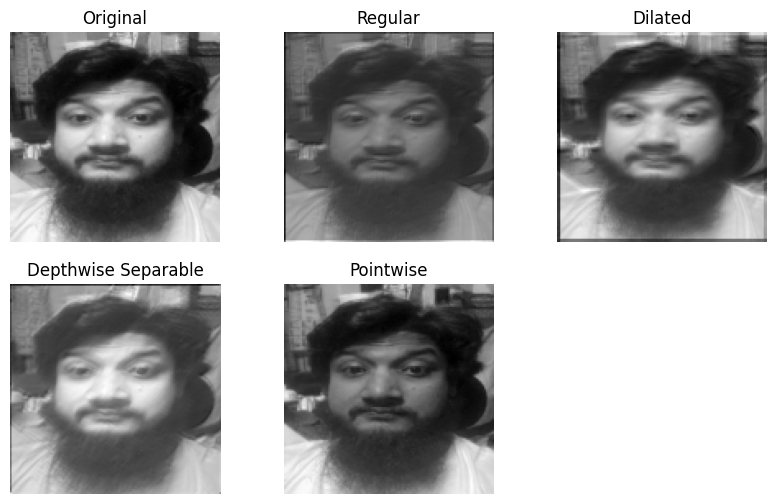

In [1]:
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import torchvision.transforms as T
from PIL import Image

# Load image
img = Image.open("Nazmul.jpg").convert("RGB")
transform = T.Compose([T.Resize((128,128)), T.ToTensor()])
x = transform(img).unsqueeze(0)

# 1. Regular Convolution
conv = nn.Conv2d(3, 8, kernel_size=3, padding=1)
out_regular = conv(x)

# 2. Dilated Convolution
dilated = nn.Conv2d(3, 8, kernel_size=3, padding=2, dilation=2)
out_dilated = dilated(x)

# 3. Depthwise Separable
depthwise = nn.Conv2d(3, 3, kernel_size=3, padding=1, groups=3)
pointwise = nn.Conv2d(3, 8, kernel_size=1)
out_sep = pointwise(depthwise(x))

# 4. Pointwise only
point = nn.Conv2d(3, 8, kernel_size=1)
out_point = point(x)

# Plot results
def show(tensor, title):
    plt.imshow(tensor[0,0].detach().numpy(), cmap='gray')
    plt.title(title)
    plt.axis('off')

plt.figure(figsize=(10,6))
plt.subplot(2,3,1); show(x, "Original")
plt.subplot(2,3,2); show(out_regular, "Regular")
plt.subplot(2,3,3); show(out_dilated, "Dilated")
plt.subplot(2,3,4); show(out_sep, "Depthwise Separable")
plt.subplot(2,3,5); show(out_point, "Pointwise")

plt.show()